<a href="https://colab.research.google.com/" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Weather Forecasting Using Machine Learning Techniques: Predictive Modeling and Analysis for Accurate Meteorological Predictions**
<hr>

**Dataset:** [Seattle Weather Dataset](https://www.kaggle.com/datasets/ananthr1/weather-prediction)





# Setting up Kaggle API for getting the dataset


In [ ]:
! pip install kaggle -q
! mkdir ~/.kaggle                       
! cp kaggle.json ~/.kaggle/              
! chmod 600 ~/.kaggle/kaggle.json        


**Put the name of the dataset that you want to use and then download the dataset**

In [ ]:
! kaggle datasets download -d ananthr1/weather-prediction    


Dataset URL: https://www.kaggle.com/datasets/ananthr1/weather-prediction
License(s): CC-BY-NC-SA-4.0
  0% 0.00/11.5k [00:00<?, ?B/s]
100% 11.5k/11.5k [00:00<00:00, 41.1MB/s]


In [ ]:
! unzip -q weather-prediction.zip    
! ls *.csv


seattle-weather.csv


# Importing Necessary Libraries
<hr>


In [ ]:
import warnings, os
warnings.filterwarnings('ignore')

import numpy as np                          
import pandas as pd                         
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns


from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline


from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score, roc_auc_score)


from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier


from sklearn.feature_selection import mutual_info_classif, SelectKBest
from sklearn.decomposition import PCA


from imblearn.over_sampling import SMOTE


from scipy import stats

import joblib
print("All libraries imported ✓")


All libraries imported ✓


In [ ]:
df = pd.read_csv('seattle-weather.csv')    

df.head(5), df.shape                       


(         date  precipitation  temp_max  temp_min  wind  weather
 0  2012-01-01            0.0      12.8       5.0   4.7  drizzle
 1  2012-01-02           10.9      10.6       2.8   4.5     rain
 2  2012-01-03            0.8      11.7       7.2   2.3     rain
 3  2012-01-04           20.3      12.2       5.6   4.7     rain
 4  2012-01-05            1.3       8.9       2.8   6.1     rain,
 (1461, 6))

# Exploratory Data Analysis
<hr>


In [6]:
print("Null values present in the file:", df.isna().sum().sum())
print("\nBasic information about the dataframe:")
df.info()

df.describe()


Null values present in the file: 0

Basic information about the dataframe:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   object 
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   object 
dtypes: float64(4), object(2)
memory usage: 68.6+ KB


,precipitation,temp_max,temp_min,wind
count,1461.000000,1461.000000,1461.000000,1461.000000
mean,3.029432,16.439083,8.234771,3.241136
std,6.680194,7.349758,5.023004,1.437825
min,0.000000,-1.600000,-7.100000,0.400000
25%,0.000000,10.600000,4.400000,2.200000
50%,0.000000,15.600000,8.300000,3.000000
75%,2.800000,22.200000,12.200000,4.000000
max,55.900000,35.600000,18.300000,9.500000


In [7]:
# Weather type label mapping
weather_types = df['weather'].unique().tolist()
WEATHER_MAP   = {i: w for i, w in enumerate(sorted(weather_types))}
print("Weather types in dataset:")
for k, v in WEATHER_MAP.items():
    print(f"  {k} → {v}")


Weather types in dataset:
  0 → drizzle
  1 → fog
  2 → rain
  3 → snow
  4 → sun


## Number of observations present in the dataset corresponding to each weather type

In [8]:
count_weather = df['weather'].value_counts().to_frame()
count_weather.columns = ['count']
count_weather['weather type'] = count_weather.index
count_weather


,count,weather type
weather,,
rain,641,rain
sun,640,sun
fog,101,fog
drizzle,53,drizzle
snow,26,snow


## Number of observations per year in the dataset

In [9]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
count_year = df.groupby('year')['weather'].count().to_frame()
count_year.columns = ['observations']
count_year


,observations
year,
2012,366
2013,365
2014,365
2015,365


## Weather Type Class Distribution (Bar Chart)



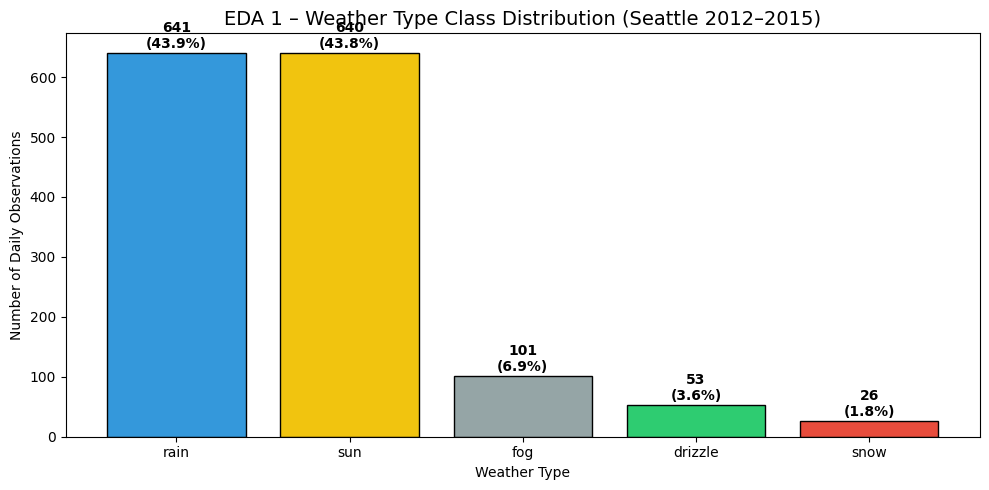

Class counts:
weather
rain       641
sun        640
fog        101
drizzle     53
snow        26


In [ ]:

counts = df['weather'].value_counts().sort_values(ascending=False)
colors = ['#3498db','#f1c40f','#95a5a6','#2ecc71','#e74c3c']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='black')
for bar, cnt in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            f'{cnt}\n({cnt/len(df)*100:.1f}%)',
            ha='center', fontsize=10, fontweight='bold')
ax.set_title('EDA 1 – Weather Type Class Distribution (Seattle 2012–2015)', fontsize=14)
ax.set_xlabel('Weather Type'); ax.set_ylabel('Number of Daily Observations')
plt.tight_layout(); plt.show()
print("Class counts:")
print(counts.to_string())


## Observations per Year (Pie Chart)



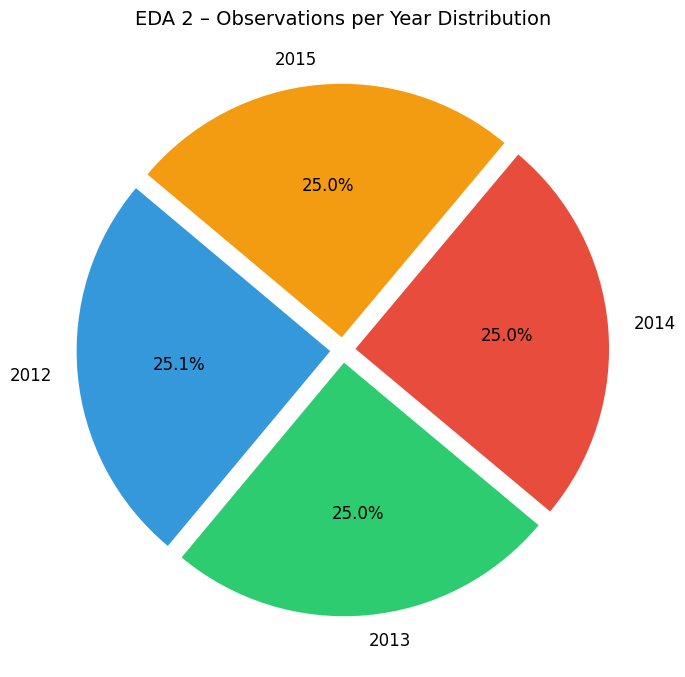

year
2012    366
2013    365
2014    365
2015    365
Name: count, dtype: int64


In [ ]:

year_counts = df['year'].value_counts().sort_index()
colors_pie  = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
explode     = [0.05] * len(year_counts)

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    year_counts.values, labels=[str(y) for y in year_counts.index],
    autopct='%1.1f%%', colors=colors_pie, explode=explode,
    startangle=140, textprops={'fontsize': 12}
)
ax.set_title('EDA 2 – Observations per Year Distribution', fontsize=14)
plt.tight_layout(); plt.show()
print(year_counts)


## Monthly Weather Frequency per Type (Grouped Bar)


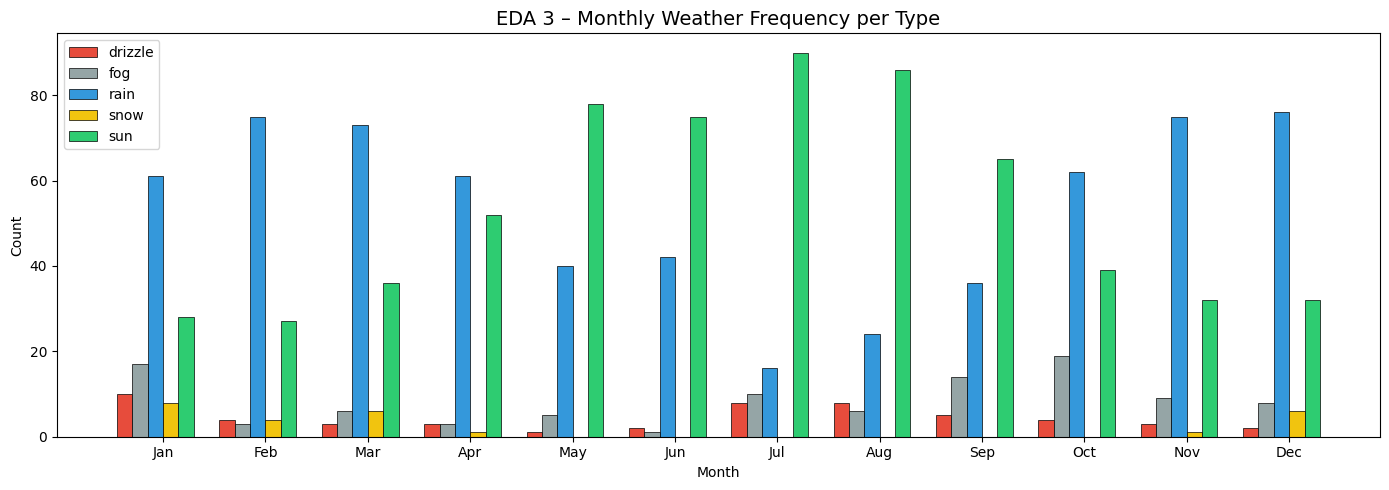

In [ ]:

df['month'] = df['date'].dt.month
weather_sorted = sorted(df['weather'].unique())
monthly_counts = df.groupby(['month','weather']).size().unstack(fill_value=0)
monthly_counts = monthly_counts.reindex(columns=weather_sorted, fill_value=0)

colors_w = ['#e74c3c','#95a5a6','#3498db','#f1c40f','#2ecc71']
x = np.arange(1, 13)
width = 0.15

fig, ax = plt.subplots(figsize=(14, 5))
for idx, (wtype, color) in enumerate(zip(weather_sorted, colors_w)):
    ax.bar(x + idx*width,
           [monthly_counts.loc[m, wtype] if m in monthly_counts.index else 0 for m in range(1,13)],
           width, label=wtype, color=color, edgecolor='black', linewidth=0.5)

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ax.set_xticks(x + width * len(weather_sorted)/2)
ax.set_xticklabels(month_names)
ax.set_title('EDA 3 – Monthly Weather Frequency per Type', fontsize=14)
ax.set_xlabel('Month'); ax.set_ylabel('Count'); ax.legend()
plt.tight_layout(); plt.show()


## Meteorological Feature Statistics per Weather Type




EDA 4 – Meteorological Feature Statistics per Weather Type
Weather       Feature   Mean   Std  Min  Max  Count
drizzle precipitation  0.000 0.000  0.0  0.0     53
drizzle      temp_max 15.926 8.812  1.1 31.7     53
drizzle      temp_min  7.111 6.182 -3.9 16.1     53
drizzle          wind  2.368 0.911  0.6  4.7     53
    fog precipitation  0.000 0.000  0.0  0.0    101
    fog      temp_max 16.757 6.775  1.7 30.6    101
    fog      temp_min  7.979 5.012 -3.2 17.8    101
    fog          wind  2.481 1.197  0.8  6.6    101
   rain precipitation  6.558 8.648  0.0 55.9    641
   rain      temp_max 13.455 4.973  3.9 35.6    641
   rain      temp_min  7.589 3.952 -3.8 18.3    641
   rain          wind  3.670 1.586  0.5  9.5    641
   snow precipitation  8.554 7.022  0.3 23.9     26
   snow      temp_max  5.573 3.109 -1.1 11.1     26
   snow      temp_min  0.146 2.237 -4.3  5.6     26
   snow          wind  4.412 1.440  1.6  7.0     26
    sun precipitation  0.000 0.000  0.0  0.0    640
    s

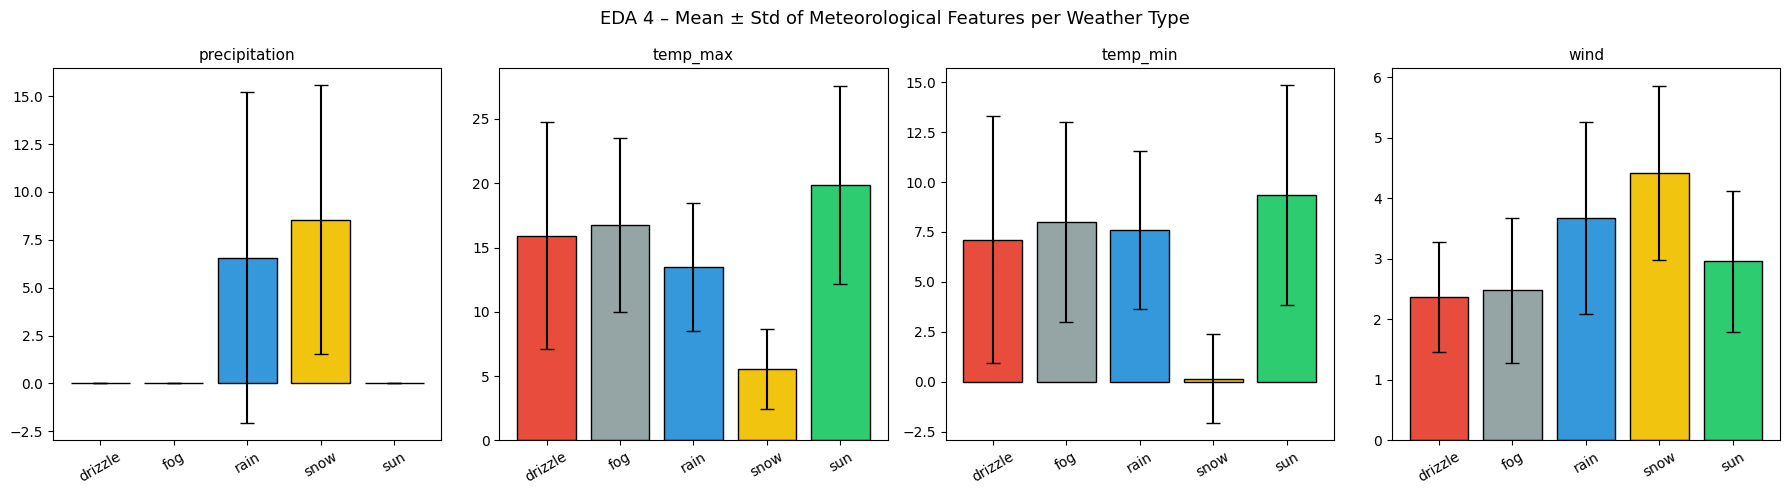

In [ ]:

numeric_feats = ['precipitation', 'temp_max', 'temp_min', 'wind']
rows = []
for wtype in sorted(df['weather'].unique()):
    sub = df[df['weather'] == wtype][numeric_feats]
    for feat in numeric_feats:
        rows.append({
            'Weather':  wtype,
            'Feature':  feat,
            'Mean':     round(sub[feat].mean(), 3),
            'Std':      round(sub[feat].std(),  3),
            'Min':      round(sub[feat].min(),  3),
            'Max':      round(sub[feat].max(),  3),
            'Count':    len(sub)
        })

stats_df = pd.DataFrame(rows)
print("EDA 4 – Meteorological Feature Statistics per Weather Type")
print(stats_df.to_string(index=False))

# Visualise mean ± std for each feature
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
weather_order = sorted(df['weather'].unique())
colors_bar    = ['#e74c3c','#95a5a6','#3498db','#f1c40f','#2ecc71']
for ax, feat in zip(axes, numeric_feats):
    means = [df[df['weather']==w][feat].mean() for w in weather_order]
    stds  = [df[df['weather']==w][feat].std()  for w in weather_order]
    ax.bar(weather_order, means, yerr=stds, color=colors_bar, edgecolor='black', capsize=5)
    ax.set_title(feat, fontsize=11)
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('EDA 4 – Mean ± Std of Meteorological Features per Weather Type', fontsize=13)
plt.tight_layout(); plt.show()


##  Sample Count Heatmap (Weather Type × Year)



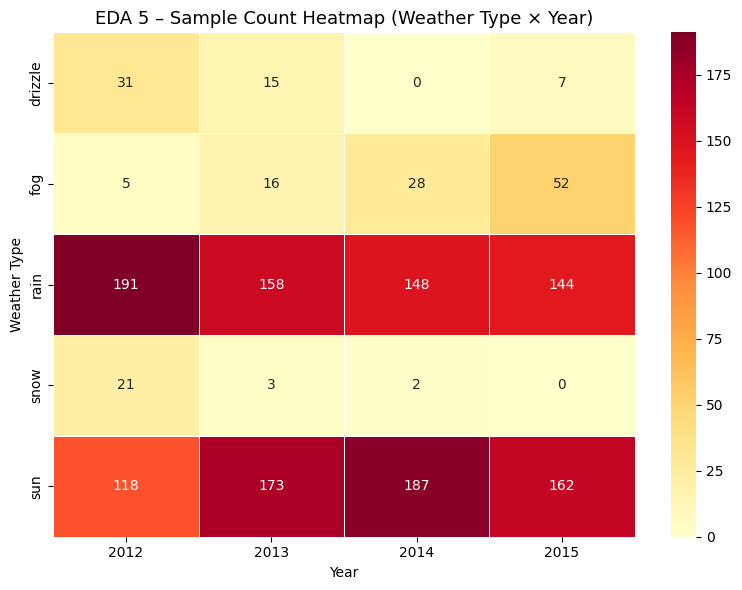

In [ ]:

years   = sorted(df['year'].unique())
weather_order = sorted(df['weather'].unique())

matrix = np.array([
    [df[(df['year']==y) & (df['weather']==w)].shape[0] for y in years]
    for w in weather_order
])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(matrix, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=[str(y) for y in years],
            yticklabels=weather_order,
            linewidths=0.5, ax=ax)
ax.set_title('EDA 5 – Sample Count Heatmap (Weather Type × Year)', fontsize=13)
ax.set_xlabel('Year'); ax.set_ylabel('Weather Type')
plt.tight_layout(); plt.show()


## Visualising the Meteorological Time-Series Data

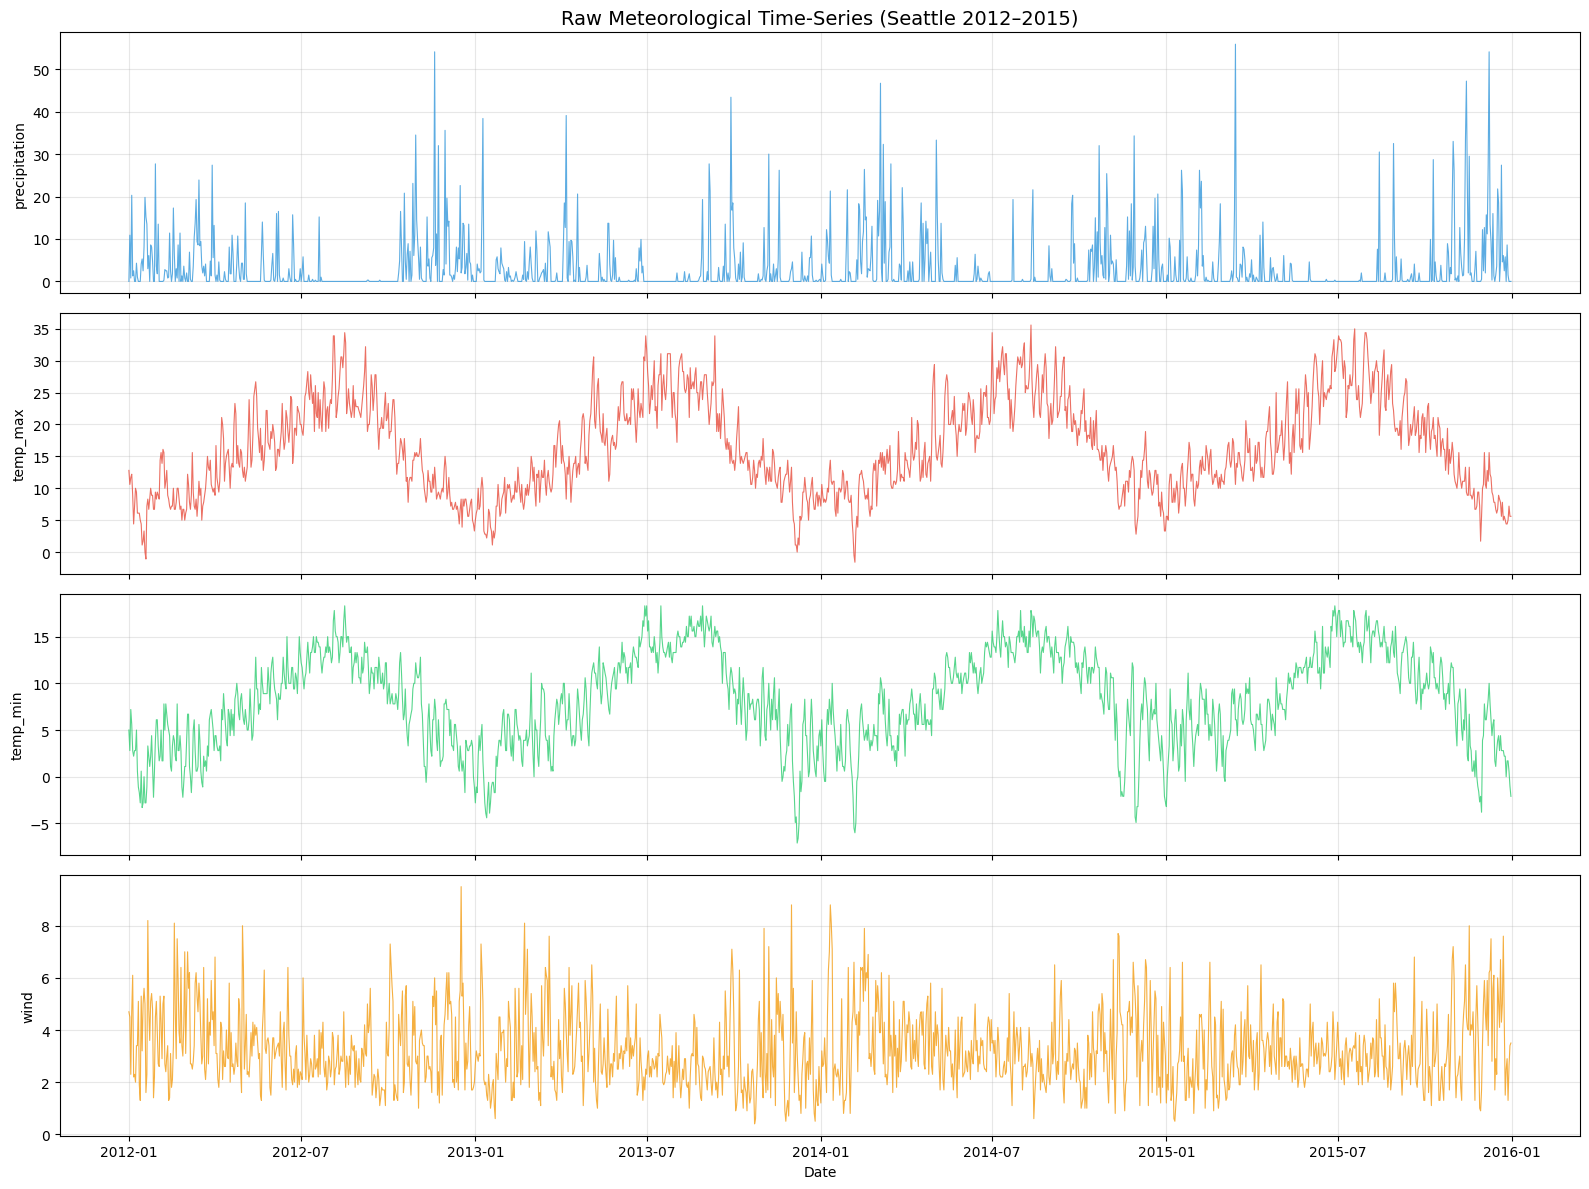

In [ ]:

numeric_feats = ['precipitation', 'temp_max', 'temp_min', 'wind']
colors_ts     = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
for ax, feat, color in zip(axes, numeric_feats, colors_ts):
    ax.plot(df['date'], df[feat], color=color, linewidth=0.8, alpha=0.8)
    ax.set_ylabel(feat, fontsize=10)
    ax.grid(True, alpha=0.3)

axes[0].set_title('Raw Meteorological Time-Series (Seattle 2012–2015)', fontsize=14)
axes[-1].set_xlabel('Date')
plt.tight_layout(); plt.show()


# Data Preprocessing
<hr>

## Feature Engineering from Raw Meteorological Observations


In [ ]:

df_feat = df.copy().sort_values('date').reset_index(drop=True)


df_feat['month']      = df_feat['date'].dt.month
df_feat['day_of_year']= df_feat['date'].dt.dayofyear
df_feat['season']     = df_feat['month'].map(
    {12:0,1:0,2:0, 3:1,4:1,5:1, 6:2,7:2,8:2, 9:3,10:3,11:3})



df_feat['month_sin']      = np.sin(2 * np.pi * df_feat['month'] / 12)
df_feat['month_cos']      = np.cos(2 * np.pi * df_feat['month'] / 12)
df_feat['doy_sin']        = np.sin(2 * np.pi * df_feat['day_of_year'] / 365)
df_feat['doy_cos']        = np.cos(2 * np.pi * df_feat['day_of_year'] / 365)


df_feat['temp_range']     = df_feat['temp_max'] - df_feat['temp_min']
df_feat['temp_mean']      = (df_feat['temp_max'] + df_feat['temp_min']) / 2


for lag in [1, 3]:
    for feat in ['precipitation', 'temp_max', 'temp_min', 'wind']:
        df_feat[f'{feat}_lag{lag}'] = df_feat[feat].shift(lag)


for feat in ['precipitation', 'temp_mean', 'wind']:
    df_feat[f'{feat}_roll7_mean'] = df_feat[feat].rolling(7, min_periods=1).mean()
    df_feat[f'{feat}_roll7_std']  = df_feat[feat].rolling(7, min_periods=1).std().fillna(0)


df_feat.dropna(inplace=True)
df_feat.reset_index(drop=True, inplace=True)

print(f"Shape after feature engineering: {df_feat.shape}")
print(f"Features created: {df_feat.shape[1] - 4} (original 4 + {df_feat.shape[1]-4} engineered)")
df_feat.head(3)


Shape after feature engineering: (1458, 30)
Features created: 26 (original 4 + 26 engineered)


,date,precipitation,temp_max,temp_min,wind,weather,year,month,day_of_year,season,...,precipitation_lag3,temp_max_lag3,temp_min_lag3,wind_lag3,precipitation_roll7_mean,precipitation_roll7_std,temp_mean_roll7_mean,temp_mean_roll7_std,wind_roll7_mean,wind_roll7_std
0,2012-01-04,20.3,12.2,5.6,4.7,rain,2012,1,4,0,...,0.0,12.8,5.0,4.7,8.000000,9.583667,8.487500,1.219546,4.050000,1.170470
1,2012-01-05,1.3,8.9,2.8,6.1,rain,2012,1,5,0,...,10.9,10.6,2.8,4.5,6.660000,8.824001,7.960000,1.583272,4.460000,1.366748
2,2012-01-06,2.5,4.4,2.2,2.2,rain,2012,1,6,0,...,0.8,11.7,7.2,2.3,5.966667,8.073083,7.183333,2.371638,4.083333,1.531557


In [ ]:

feature_cols = [c for c in df_feat.columns
                if c not in ['date','weather','year']]
print(f"Total features for modelling: {len(feature_cols)}")
print(feature_cols)


Total features for modelling: 27
['precipitation', 'temp_max', 'temp_min', 'wind', 'month', 'day_of_year', 'season', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'temp_range', 'temp_mean', 'precipitation_lag1', 'temp_max_lag1', 'temp_min_lag1', 'wind_lag1', 'precipitation_lag3', 'temp_max_lag3', 'temp_min_lag3', 'wind_lag3', 'precipitation_roll7_mean', 'precipitation_roll7_std', 'temp_mean_roll7_mean', 'temp_mean_roll7_std', 'wind_roll7_mean', 'wind_roll7_std']


**The raw features are now expanded with lag, rolling, cyclical, and temperature-range features to give the models temporal context for each prediction.**

In [ ]:

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

le = LabelEncoder()
df_feat['label'] = le.fit_transform(df_feat['weather'])
CLASS_NAMES = list(le.classes_)
print("Encoded classes:", {i: c for i, c in enumerate(CLASS_NAMES)})

X = df_feat[feature_cols].values.astype(np.float32)
y = df_feat['label'].values


X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)


smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print(f"\nTrain : {X_train.shape}  | Val : {X_val.shape}  | Test : {X_test.shape}")
print(f"Train class balance after SMOTE: {np.bincount(y_train)}")


Encoded classes: {0: 'drizzle', 1: 'fog', 2: 'rain', 3: 'snow', 4: 'sun'}

Train : (2240, 27)  | Val : (219, 27)  | Test : (219, 27)
Train class balance after SMOTE: [448 448 448 448 448]


##  Feature Scaling Verification



In [ ]:

for name, arr in [('X_train', X_train), ('X_val', X_val), ('X_test', X_test)]:
    print(f"{name}: mean≈{arr.mean():.4f}  std≈{arr.std():.4f}  "
          f"min={arr.min():.3f}  max={arr.max():.3f}  "
          f"zero_mean={bool(abs(arr.mean())<0.01)}")


X_train: mean≈-0.0967  std≈1.0361  min=-3.061  max=8.020  zero_mean=False
X_val: mean≈-0.0217  std≈0.9827  min=-2.825  max=7.466  zero_mean=False
X_test: mean≈-0.0078  std≈1.0161  min=-3.043  max=7.747  zero_mean=True


## Class Balance After SMOTE (Bar Chart per Split)



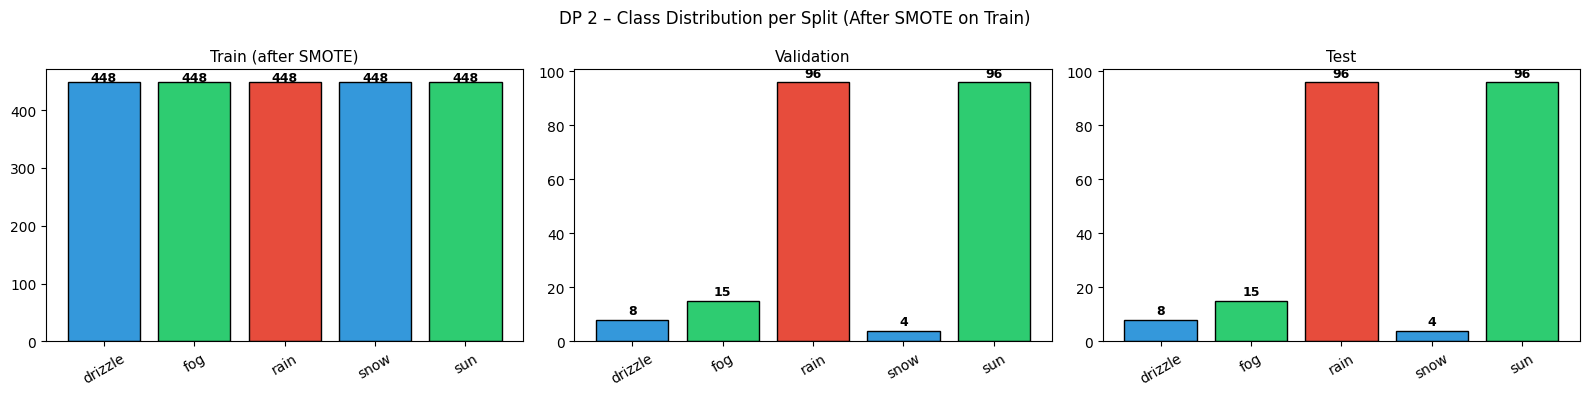

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
split_colors = ['#3498db', '#2ecc71', '#e74c3c']
for ax, (name, y_arr), col in zip(
        axes,
        [('Train (after SMOTE)', y_train), ('Validation', y_val), ('Test', y_test)],
        split_colors):
    unique, counts_arr = np.unique(y_arr, return_counts=True)
    ax.bar([CLASS_NAMES[u] for u in unique], counts_arr,
           color=split_colors, edgecolor='black')
    ax.set_title(f'{name}', fontsize=11)
    ax.tick_params(axis='x', rotation=30)
    for i, (u, c) in enumerate(zip(unique, counts_arr)):
        ax.text(i, c + 2, str(c), ha='center', fontsize=9, fontweight='bold')
plt.suptitle('DP 2 – Class Distribution per Split (After SMOTE on Train)', fontsize=12)
plt.tight_layout(); plt.show()


## Data Processing 3 – Feature Correlation Matrix (Selected Features)


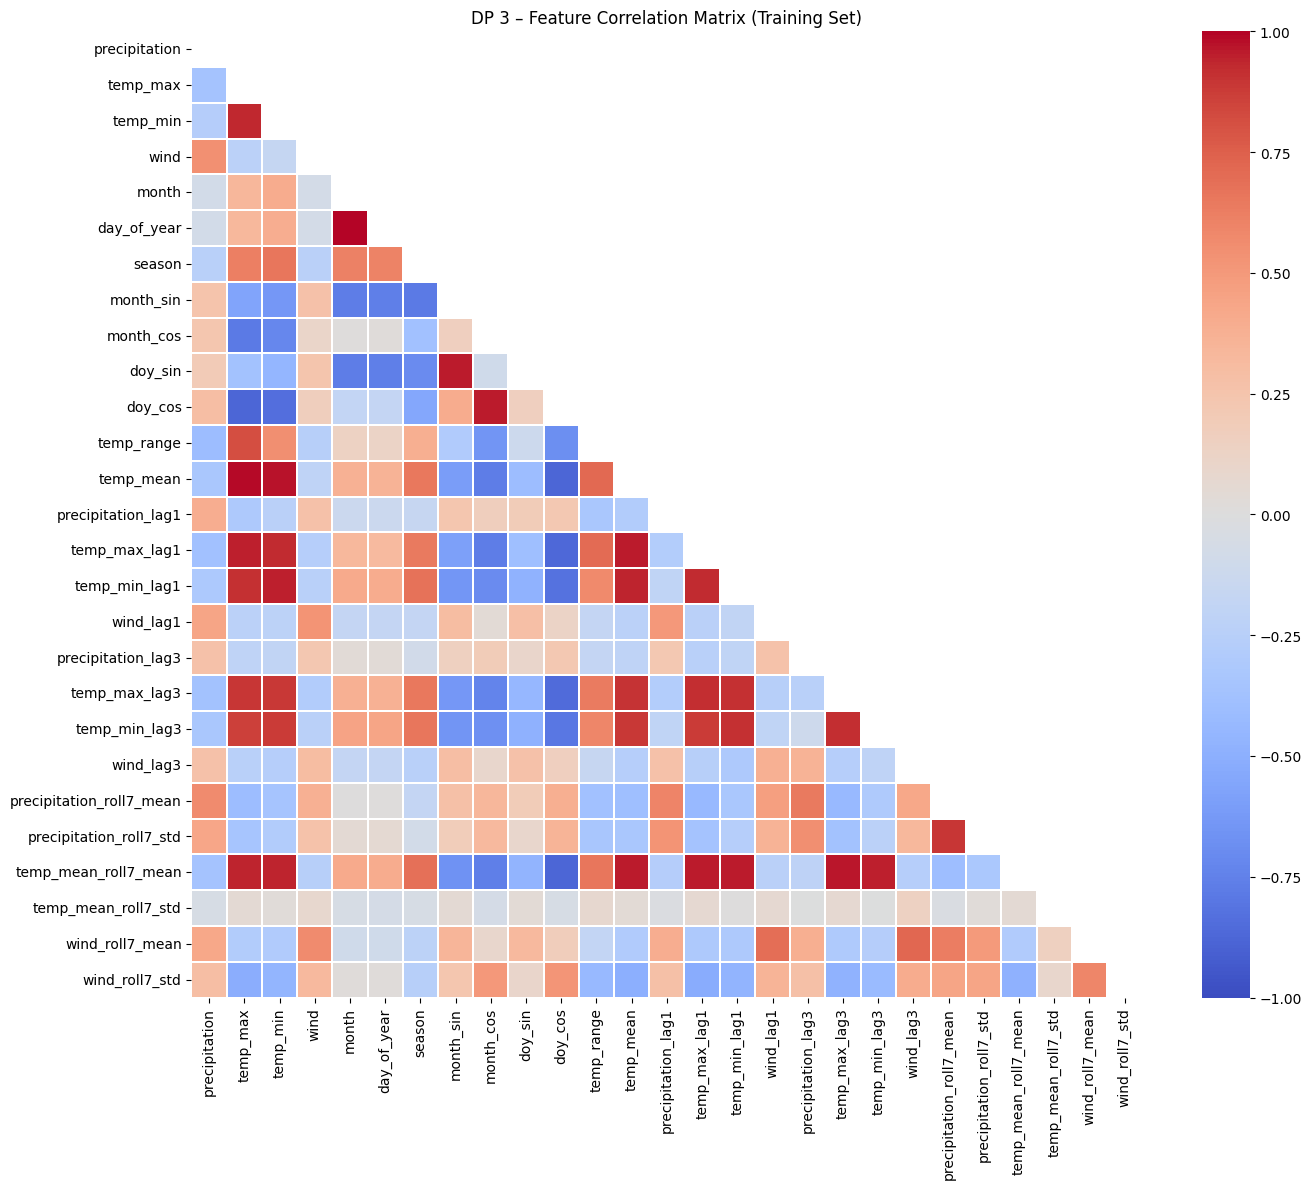

High-correlation pairs (|r|>0.9): 25
  temp_max  ↔  temp_min
  temp_max  ↔  temp_mean
  temp_max  ↔  temp_max_lag1
  temp_max  ↔  temp_min_lag1
  temp_max  ↔  temp_mean_roll7_mean
  temp_min  ↔  temp_mean
  temp_min  ↔  temp_max_lag1
  temp_min  ↔  temp_min_lag1
  temp_min  ↔  temp_mean_roll7_mean
  month  ↔  day_of_year


In [ ]:

corr_df = pd.DataFrame(X_train, columns=feature_cols).corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, mask=mask, cmap='coolwarm', center=0, annot=False,
            linewidths=0.3, ax=ax, vmin=-1, vmax=1)
ax.set_title('DP 3 – Feature Correlation Matrix (Training Set)', fontsize=12)
plt.tight_layout(); plt.show()

high_corr = [(corr_df.columns[i], corr_df.columns[j])
             for i in range(len(corr_df))
             for j in range(i+1, len(corr_df))
             if abs(corr_df.iloc[i,j]) > 0.9]
print(f"High-correlation pairs (|r|>0.9): {len(high_corr)}")
for pair in high_corr[:10]:
    print(f"  {pair[0]}  ↔  {pair[1]}")


## Mutual Information Feature Importance Ranking


Top 15 Features by Mutual Information Score:
precipitation              0.737749
temp_max                   0.653229
wind                       0.641873
temp_min_lag1              0.613371
temp_max_lag1              0.610613
temp_range                 0.598591
temp_min_lag3              0.584191
temp_max_lag3              0.582366
temp_min                   0.575473
temp_mean                  0.569422
wind_lag1                  0.517067
wind_lag3                  0.488727
month                      0.417375
temp_mean_roll7_mean       0.415269
precipitation_roll7_std    0.382059


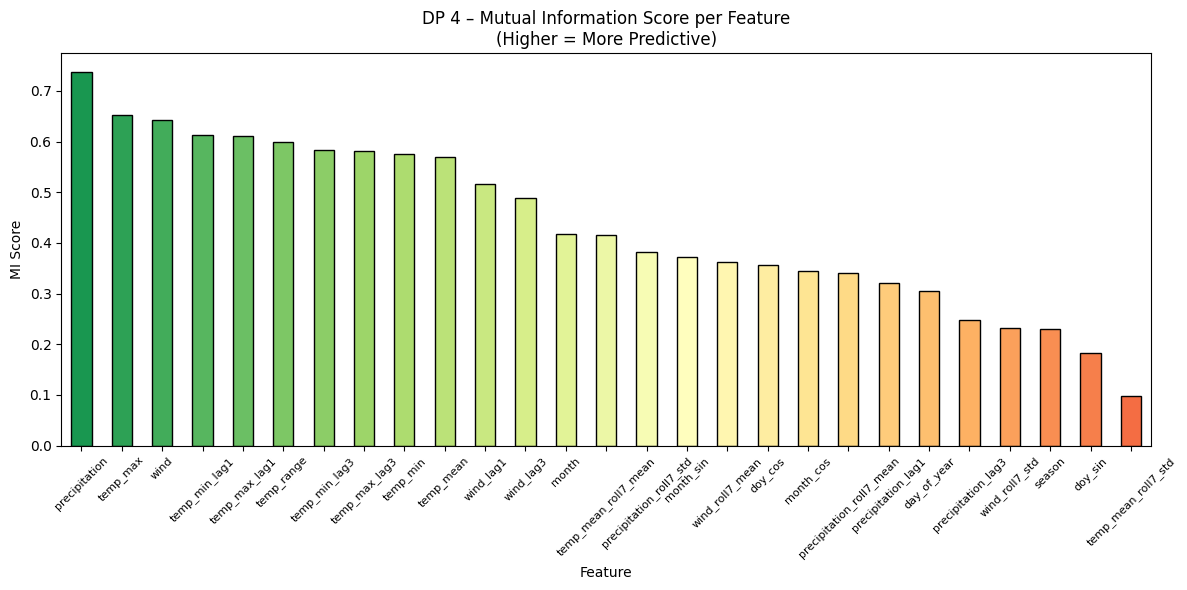

In [ ]:

from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
mi_df = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)

print("Top 15 Features by Mutual Information Score:")
print(mi_df.head(15).to_string())

fig, ax = plt.subplots(figsize=(12, 6))
colors_mi = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(mi_df)))[::-1]
mi_df.plot(kind='bar', color=colors_mi, edgecolor='black', ax=ax)
ax.set_title('DP 4 – Mutual Information Score per Feature\n(Higher = More Predictive)', fontsize=12)
ax.set_xlabel('Feature'); ax.set_ylabel('MI Score')
ax.tick_params(axis='x', rotation=45, labelsize=8)
plt.tight_layout(); plt.show()


## Train / Val / Test Shape & Memory Report


In [ ]:

for name, X_arr, y_arr in [('Train', X_train, y_train),
                             ('Val',   X_val,   y_val),
                             ('Test',  X_test,  y_test)]:
    mb = X_arr.nbytes / (1024**2)
    print(f"{name:6s}: X={X_arr.shape}  y={y_arr.shape}  "
          f"dtype={X_arr.dtype}  memory≈{mb:.3f} MB")
print(f"\nFeature vector length fed to each model: {X_train.shape[1]}")


Train : X=(2240, 27)  y=(2240,)  dtype=float32  memory≈0.231 MB
Val   : X=(219, 27)  y=(219,)  dtype=float32  memory≈0.023 MB
Test  : X=(219, 27)  y=(219,)  dtype=float32  memory≈0.023 MB

Feature vector length fed to each model: 27
